In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
import pandas as pd
import numpy as np; print(np.__version__)
df = pd.read_csv("merged_crop_dataset.csv")
print("--- Dataset Preview ---")
print(df.head())

df.info()
df=df.rename({"P": "Phosphorous", "K": "Potassium", "N": "Nitrogen", "temperature": "Temperature", "humidity": "Humidity", "ph": "pH", "rainfall": "Rainfall", "label": "Crop"}, axis=1)
print(df.head())

2.5.1
--- Dataset Preview ---
    N    P    K  temperature   humidity        ph    rainfall  label
0  24  128  196    22.750888  90.694892  5.521467  110.431786  apple
1   7  144  197    23.849401  94.348150  6.133221  114.051249  apple
2  14  128  205    22.608010  94.589006  6.226290  116.039659  apple
3   8  120  201    21.186674  91.134357  6.321152  122.233323  apple
4  20  129  201    23.410447  91.699133  5.587906  116.077793  apple
<class 'pandas.DataFrame'>
RangeIndex: 6596 entries, 0 to 6595
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            6596 non-null   int64  
 1   P            6596 non-null   int64  
 2   K            6596 non-null   int64  
 3   temperature  6596 non-null   float64
 4   humidity     6596 non-null   float64
 5   ph           6596 non-null   float64
 6   rainfall     6596 non-null   float64
 7   label        6596 non-null   str    
dtypes: float64(4), int64(3), str(1)
memo

In [3]:
df.describe()

,Nitrogen,Phosphorous,Potassium,Temperature,Humidity,pH,Rainfall
count,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000,6596.000000
mean,65.334900,48.164494,50.290024,25.397240,73.407185,5.862800,531.003576
std,45.431015,23.699351,39.812887,5.052873,17.588425,0.756141,599.989529
min,0.000000,5.000000,5.000000,1.180000,14.258040,3.504752,3.274569
25%,26.000000,35.000000,20.000000,22.676000,61.251404,5.340000,89.740866
50%,50.000000,48.000000,39.000000,26.002745,81.209600,5.680000,199.212500
75%,90.000000,60.000000,65.000000,28.545455,85.612917,6.379911,942.800000
max,180.000000,145.000000,205.000000,43.675493,99.981876,9.935091,3322.060000


In [4]:
print(df.isnull().sum())
df = df.dropna()
X=df.drop("Crop", axis=1)
y=df["Crop"]
print("Target Classes:")

for i, name in enumerate(y.unique(), start=0):
    print(i, "->", name)

Nitrogen       0
Phosphorous    0
Potassium      0
Temperature    0
Humidity       0
pH             0
Rainfall       0
Crop           0
dtype: int64
Target Classes:
0 -> apple
1 -> banana
2 -> barley
3 -> bitter_gourd
4 -> blackgram
5 -> blackpepper
6 -> bottle_gourd
7 -> brinjal
8 -> cabbage
9 -> cardamom
10 -> cauliflower
11 -> chickpea
12 -> coconut
13 -> coffee
14 -> coriander
15 -> cotton
16 -> cucumber
17 -> drumstick
18 -> garlic
19 -> grapes
20 -> horsegram
21 -> jackfruit
22 -> jute
23 -> kidneybeans
24 -> lentil
25 -> maize
26 -> mango
27 -> mothbeans
28 -> mungbean
29 -> muskmelon
30 -> okra
31 -> onion
32 -> orange
33 -> papaya
34 -> pigeonpeas
35 -> pineapple
36 -> pomegranate
37 -> potato
38 -> pumpkin
39 -> radish
40 -> ragi
41 -> rapeseed
42 -> rice
43 -> sorghum
44 -> soybean
45 -> sunflower
46 -> sweet_potato
47 -> tomato
48 -> turmeric
49 -> watermelon
50 -> wheat


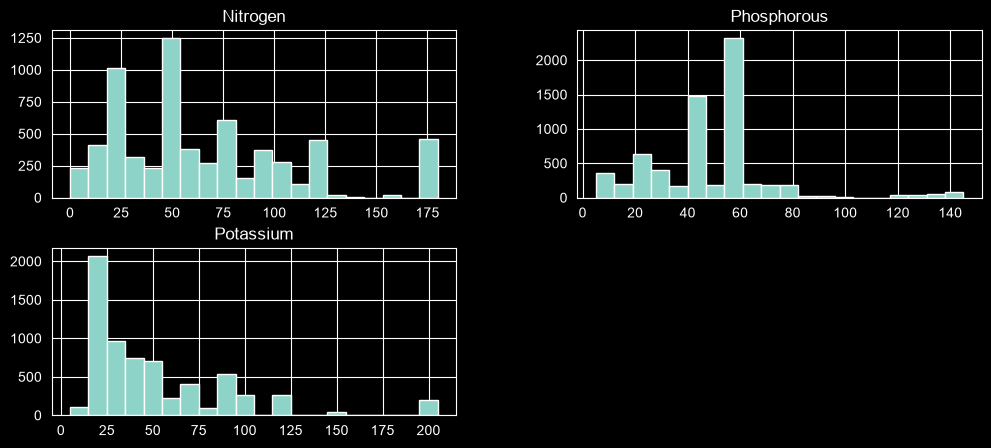

In [5]:
num_cols = [
    'Nitrogen',
    'Phosphorous',
    'Potassium'
]

df[num_cols].hist(
    figsize=(12,5),
    bins=20
)

plt.show()

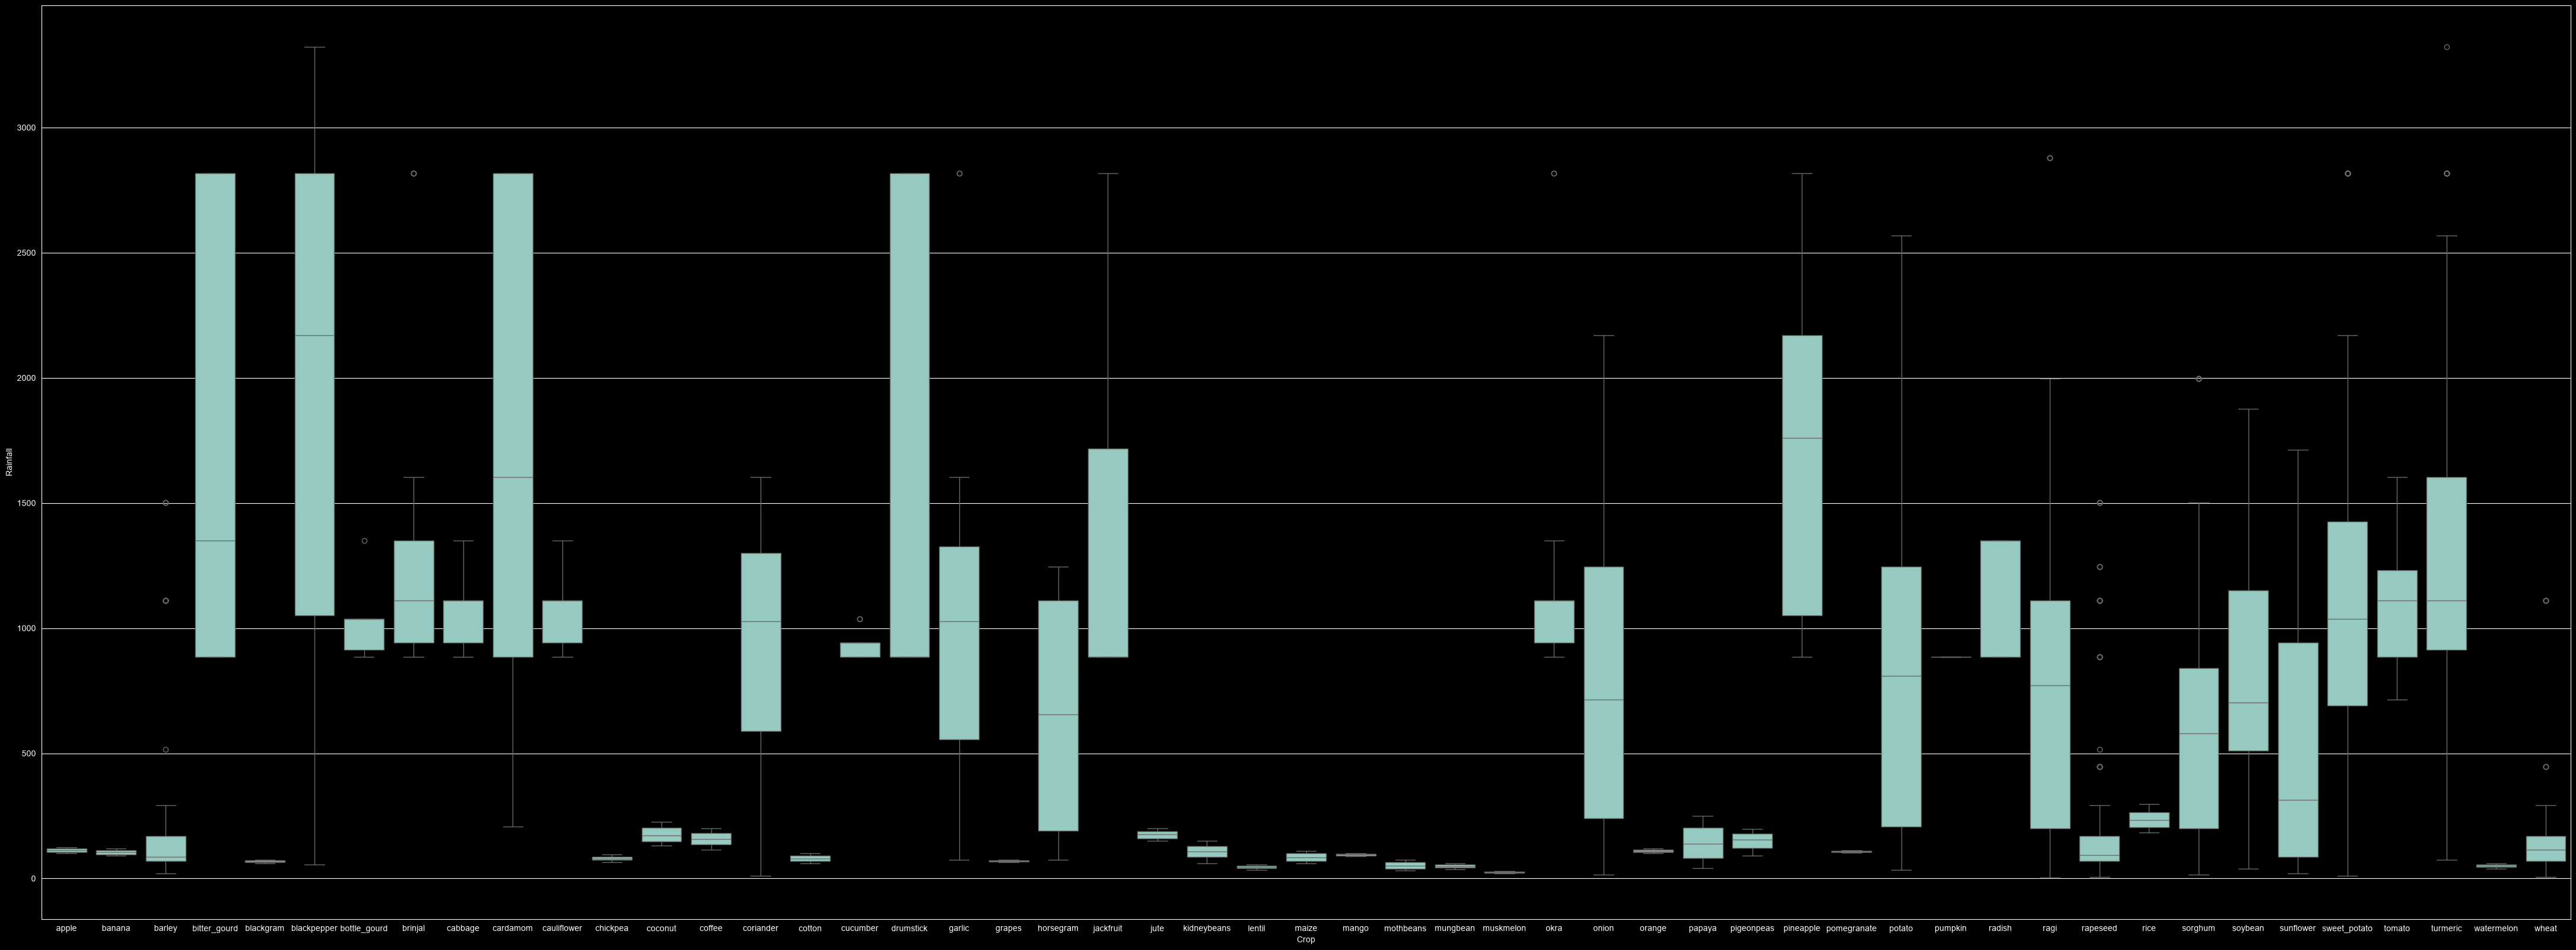

In [6]:
plt.figure(figsize=(55,20))

sns.boxplot(
    data=df,
    x='Crop',
    y='Rainfall',
)

plt.show()

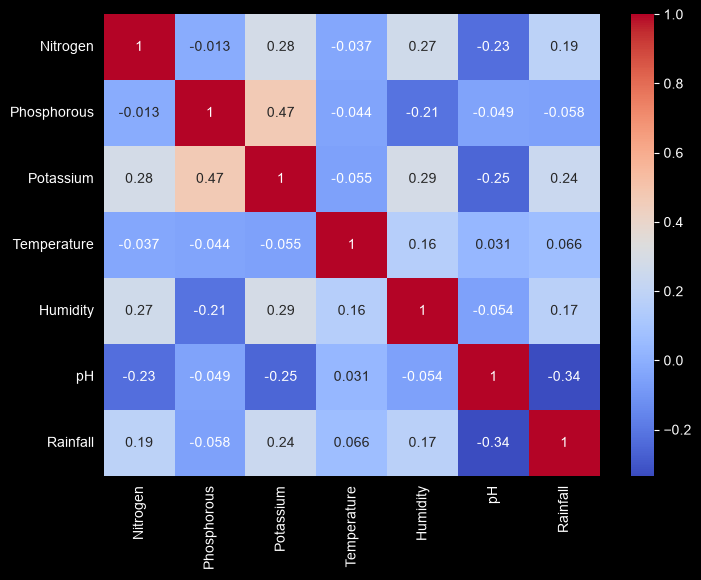

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


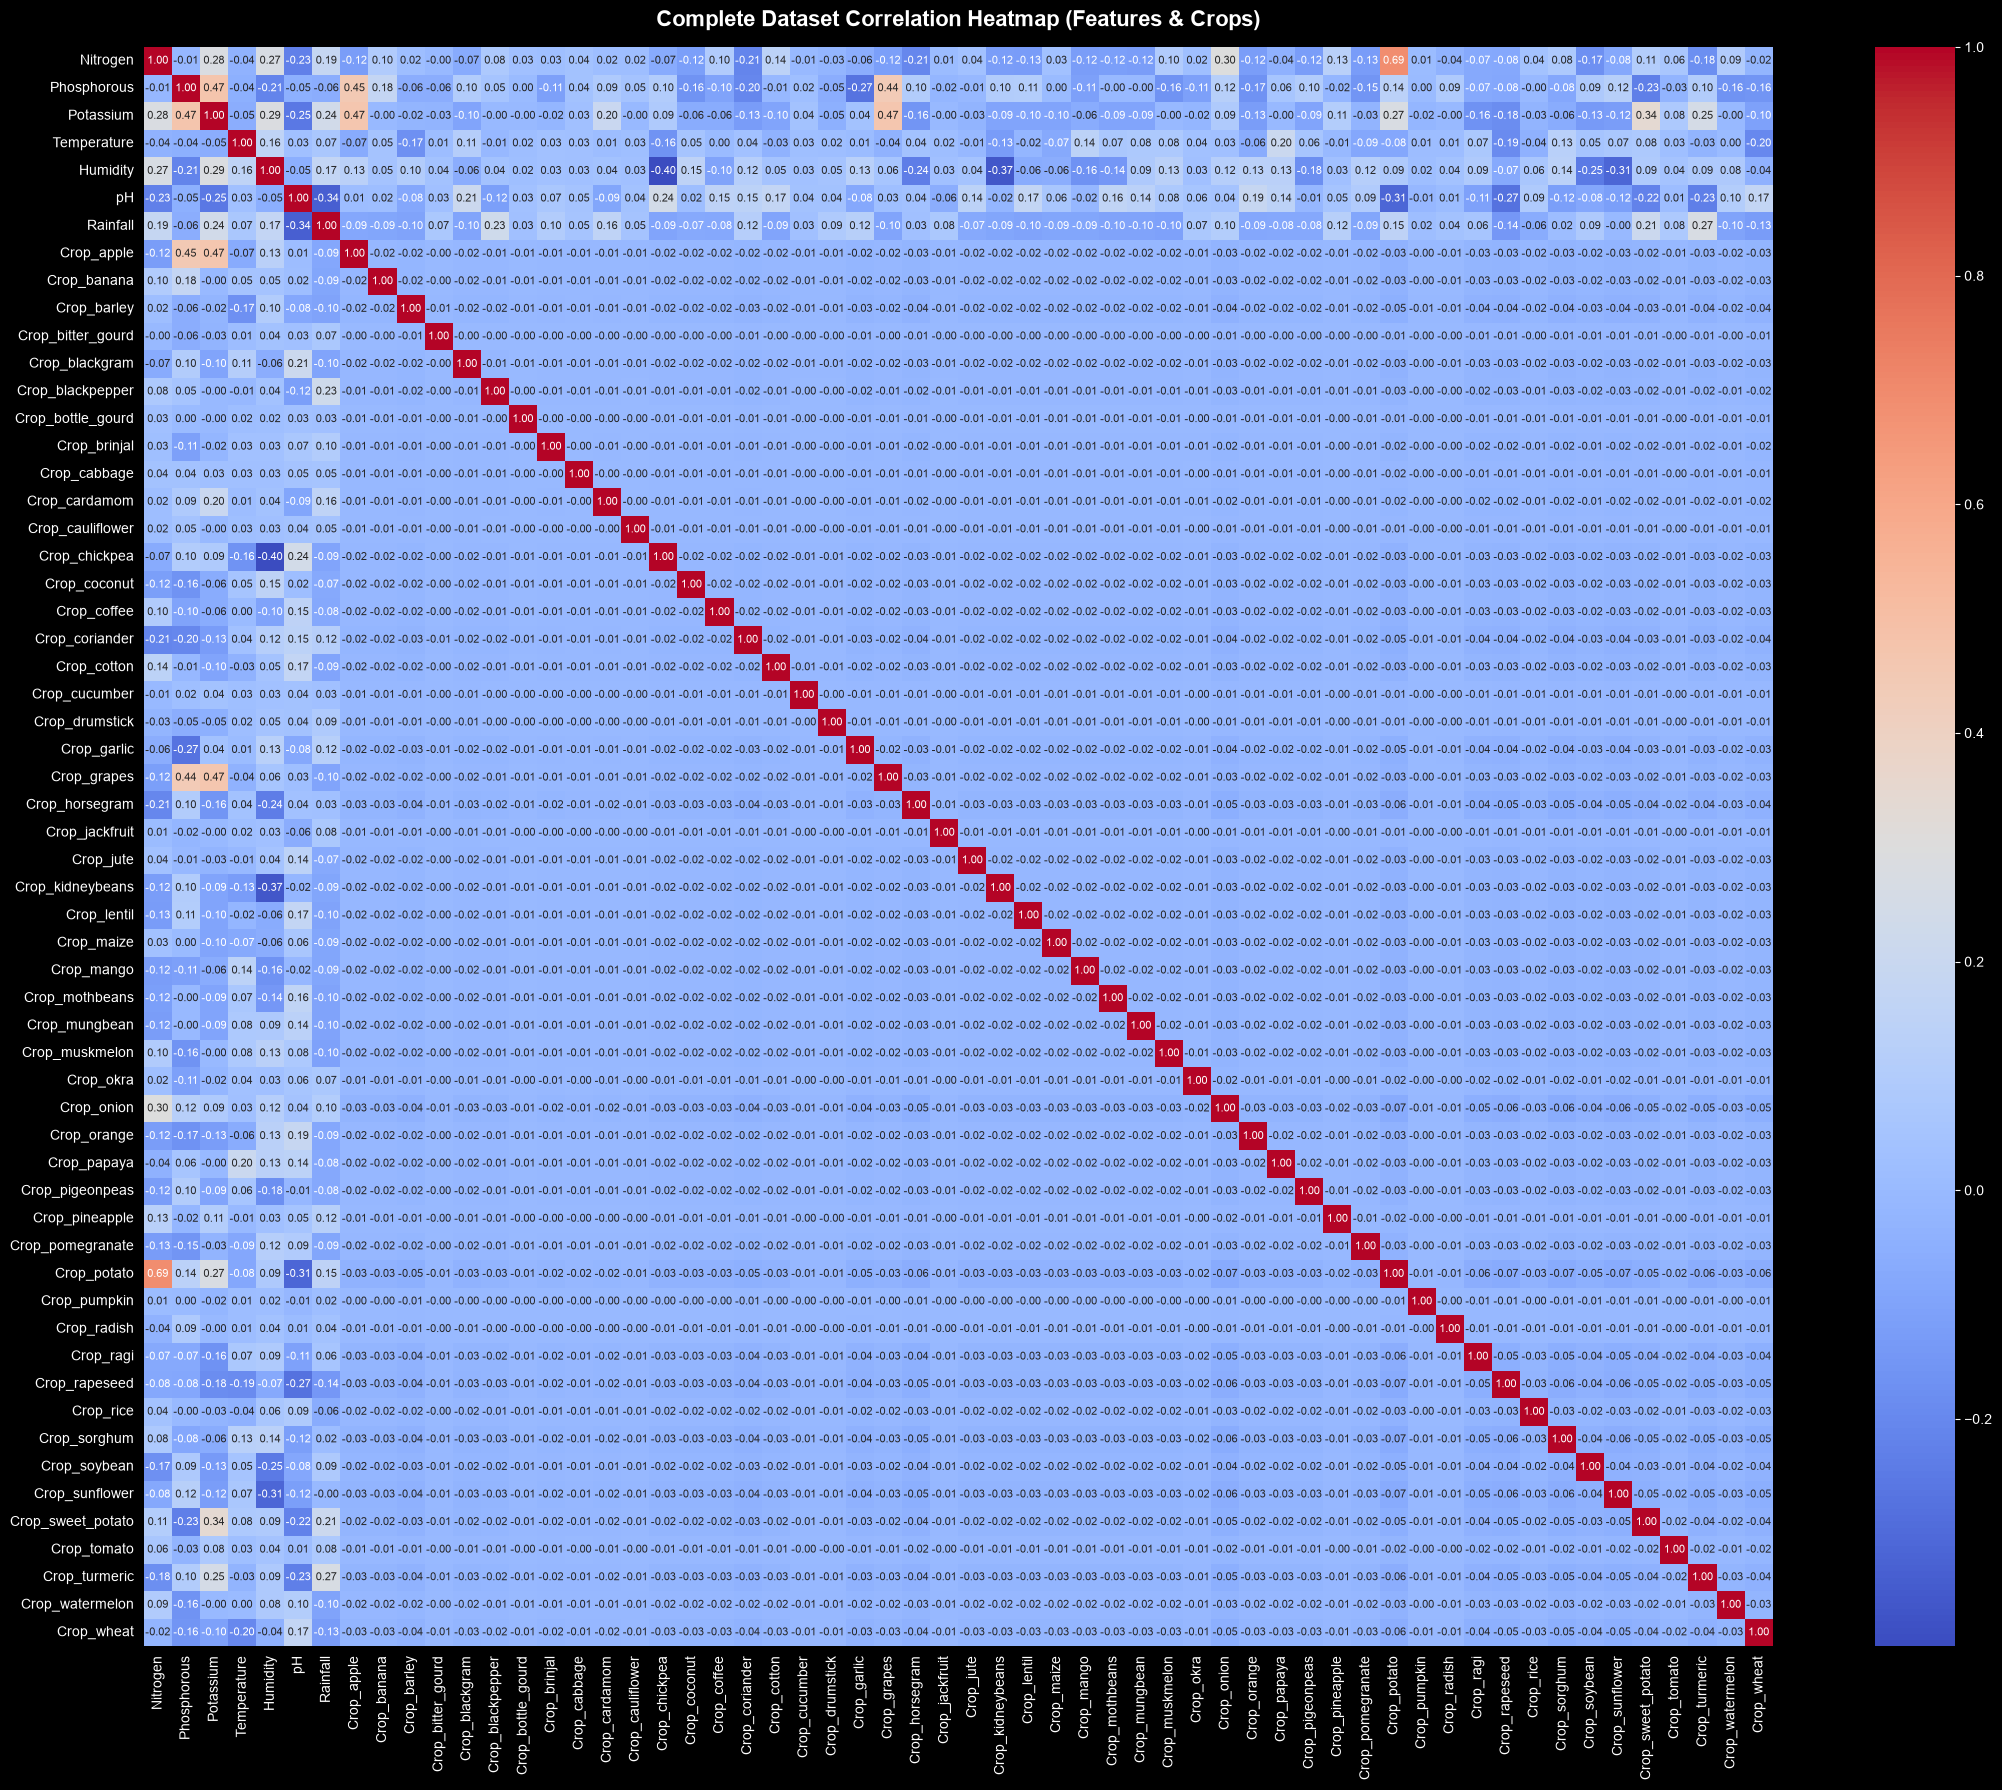

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert the crop 'label' text column into numeric 0s and 1s
df_numeric = pd.get_dummies(df, dtype=int)

# 2. Plot the heatmap exactly like your original layout
plt.figure(figsize=(22, 18))  # Made larger so all 29 columns fit cleanly

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 8}      # Shrinks text slightly so numbers fit inside squares
)

plt.title('Complete Dataset Correlation Heatmap (Features & Crops)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_4892\4258249576.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


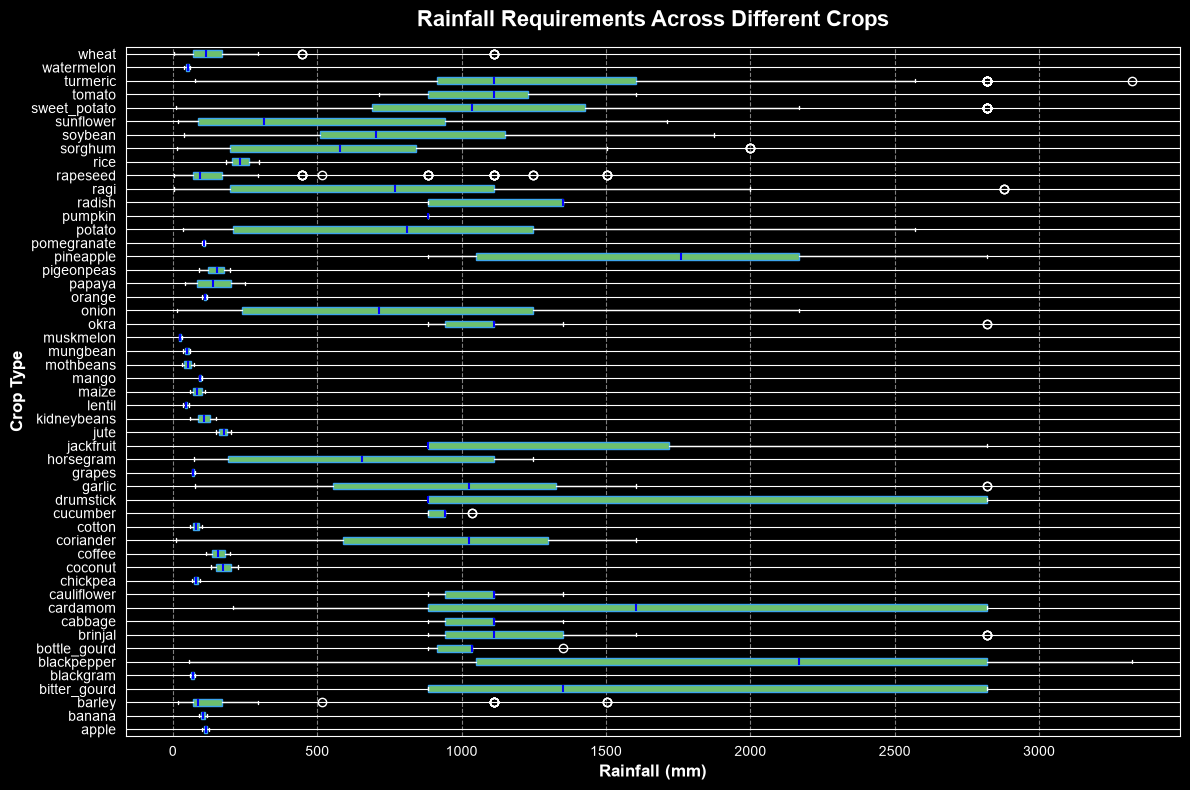

In [10]:
import matplotlib.pyplot as plt

# 1. Group the rainfall data by each unique crop label
unique_crops = df['Crop'].unique()
grouped_rainfall = [df[df['Crop'] == crop]['Rainfall'] for crop in unique_crops]

# 2. Set up the figure size
plt.figure(figsize=(12, 8))

# 3. Create the horizontal boxplot
# vert=False makes it horizontal so the crop names are easy to read.
plt.boxplot(
    grouped_rainfall, 
    vert=False, 
    tick_labels=unique_crops, 
    patch_artist=True,  
    boxprops=dict(facecolor="#6dc06d", color="#3DA4ED"), 
    medianprops=dict(color='blue', linewidth=1.5)       
)

# 4. Add labels and grid
plt.title('Rainfall Requirements Across Different Crops', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rainfall (mm)', fontsize=12, fontweight='bold')
plt.ylabel('Crop Type', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5) 
plt.tight_layout()


plt.show()

In [11]:
cat_cols = X.select_dtypes(
    include=['object', 'string']
).columns

num_cols = X.select_dtypes(
    exclude='object'
).columns

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            Pipeline([
                
                ('scaler', StandardScaler())
            ]),
            num_cols
        ),

        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ]
)

In [13]:
log_model = Pipeline([

    ('preprocessor', preprocessor),

    (
        'classifier',
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](51,)","['apple','banana','barley',...,'turmeric','watermelon','wheat']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Nitrogen','Phosphorous','Potassium',...,'Humidity','pH','Rainfall']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [14]:
pred = log_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)


Accuracy: 0.9272727272727272
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       0.84      0.95      0.89        38
bitter_gourd       0.00      0.00      0.00         2
   blackgram       0.80      1.00      0.89        20
 blackpepper       1.00      0.93      0.96        14
bottle_gourd       0.00      0.00      0.00         2
     brinjal       0.73      0.89      0.80         9
     cabbage       1.00      0.50      0.67         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      0.95      0.97        38
      cotton       1.00      0.95      0.97        20
    cucumber       1.00      1.00      1.00         

C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [15]:
rf_model = Pipeline([

    ('preprocessor', preprocessor),

    (
        'classifier',
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](51,)","['apple','banana','barley',...,'turmeric','watermelon','wheat']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Nitrogen','Phosphorous','Potassium',...,'Humidity','pH','Rainfall']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [16]:
rf_pred = rf_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.9954545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
      barley       1.00      1.00      1.00        38
bitter_gourd       1.00      1.00      1.00         2
   blackgram       1.00      0.95      0.97        20
 blackpepper       1.00      1.00      1.00        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00      1.00      1.00        20
    cucumber       1.00      1.00      1.00         

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)

pred_knn = knn_pipeline.predict(X_test)

print(
    "KNN Pipeline Accuracy:",
    accuracy_score(
        y_test, 
        pred_knn
    )
)

print(
    classification_report(
        y_test, 
        pred_knn
    )
)

KNN Pipeline Accuracy: 0.9643939393939394
              precision    recall  f1-score   support

       apple       0.91      1.00      0.95        20
      banana       1.00      1.00      1.00        20
      barley       0.93      1.00      0.96        38
bitter_gourd       1.00      0.50      0.67         2
   blackgram       0.73      0.95      0.83        20
 blackpepper       1.00      0.93      0.96        14
bottle_gourd       1.00      1.00      1.00         2
     brinjal       0.82      1.00      0.90         9
     cabbage       1.00      1.00      1.00         4
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         4
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
   coriander       1.00      1.00      1.00        38
      cotton       1.00      1.00      1.00        20
    cucumber       1.00      1.00      

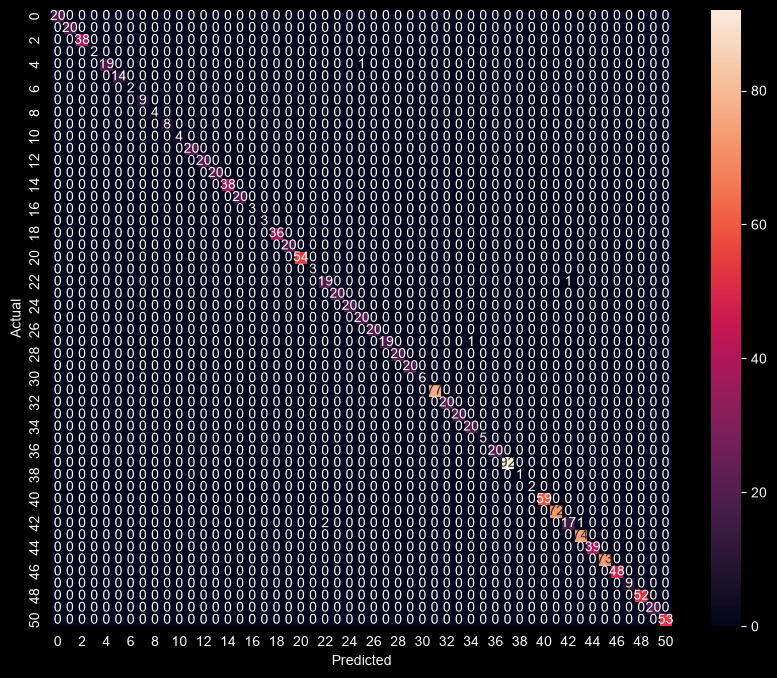

In [18]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline

# Import your 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. SPLIT DATA & ENCODE TARGET (y)
# ==========================================
X = df.drop(columns=['Crop'])  # Features: N, P, K, temperature, humidity, ph, rainfall
y = df['Crop']  # Target: Crop labels

# Encode the text crop target labels into numeric IDs
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

# Split into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# ==========================================
# 2. CREATE THE PREPROCESSING PIPELINE
# ==========================================
# Identify any categorical columns left in X (if any text columns exist in features)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# The ColumnTransformer applies One-Hot Encoding ONLY to categorical columns,
# and lets numerical columns (like N, P, K, Rainfall) pass through untouched.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keeps your N, P, K, rainfall columns exactly as they are
)

# ==========================================
# 3. DEFINE AND EVALUATE THE 3 MODELS
# ==========================================
# We put our 3 models into a dictionary so we can loop through them cleanly
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42
            )}


print("--- Training and Evaluating Models --- \n")

# Loop through each model, attach it to the preprocessing pipeline, and score it
for name, model in models.items():
    # Create the complete pipeline: First preprocess data, then fit the model
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train the pipeline
    clf_pipeline.fit(X_train, y_train)
    
    # Predict on unseen test data
    y_pred = clf_pipeline.predict(X_test)
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    
    print(f"=========================================")
    print(f"🏆 {name} Performance")
    print(f"=========================================")
    print(f"Accuracy Score: {acc * 100:.2f}%")
    print("\nClassification Report:")
    # target_names maps the numeric predictions back to original crop names (e.g., 'rice')
    print(
        classification_report(
            y_test,
            y_pred,
            labels=range(len(label_enc.classes_)),
            target_names=label_enc.classes_
        )
    )
    print("\n")

--- Training and Evaluating Models --- 



C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syeda\PycharmProjects\MLproject\.

🏆 Logistic Regression Performance
Accuracy Score: 90.83%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        25
      banana       0.95      1.00      0.98        21
      barley       0.79      0.92      0.85        48
bitter_gourd       1.00      1.00      1.00         1
   blackgram       0.64      0.72      0.68        25
 blackpepper       1.00      0.94      0.97        16
bottle_gourd       1.00      1.00      1.00         2
     brinjal       1.00      1.00      1.00        10
     cabbage       1.00      1.00      1.00         2
    cardamom       1.00      1.00      1.00         8
 cauliflower       1.00      1.00      1.00         3
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      0.93      0.96        14
      coffee       1.00      1.00      1.00        13
   coriander       1.00      1.00      1.00        44
      cotton       0.94      0.94      0.94        16


C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syeda\PycharmProjects\MLproject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric